# Recomendador por emocion y actividad

Cuaderno para construir el catalogo clasificado y entrenar el
modelo de recomendacion.

## 0. Configuracion del notebook

In [1]:
%matplotlib inline

SOURCE = "auto"
MAX_RECOMMENDER_TRAINING_ROWS = 200_000
MAX_RECOMMENDER_EVAL_ROWS = 50_000
UPLOAD_TO_S3 = True
S3_RECOMMENDER_PREFIX = "models/activity_recommender"

## 1. Funciones internas

In [2]:
from __future__ import annotations

import argparse
import json
import logging
import shutil
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import boto3
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import load_settings

LOGGER = logging.getLogger("build_recommender_notebook")

RANDOM_STATE = 42
MAX_RECOMMENDER_TRAINING_ROWS = 200_000
MAX_RECOMMENDER_EVAL_ROWS = 50_000

FEATURE_COLS = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "loudness",
    "tempo",
    "spec_rate",
    "duration_ms",
]

LABEL_NAMES = {
    0: "sad",
    1: "happy",
    2: "energetic",
    3: "calm",
}

MOOD_TO_LABEL = {value: key for key, value in LABEL_NAMES.items()}

ACTIVITY_PROFILE_COLS = [
    "activity_movement",
    "activity_energy",
    "activity_positivity",
    "activity_focus",
    "activity_calm",
    "activity_acoustic",
]

KNOWN_ACTIVITIES = {
    "llorar": [0.00, 0.05, 0.05, 0.30, 0.95, 0.85],
    "desahogarme": [0.00, 0.10, 0.10, 0.35, 0.90, 0.80],
    "estar triste": [0.05, 0.10, 0.10, 0.35, 0.90, 0.80],
    "gym": [0.95, 0.95, 0.65, 0.45, 0.10, 0.15],
    "entrenar": [0.95, 0.95, 0.65, 0.45, 0.10, 0.15],
    "correr": [1.00, 0.95, 0.70, 0.35, 0.05, 0.10],
    "bailar": [0.95, 0.90, 0.95, 0.20, 0.05, 0.05],
    "limpiar": [0.75, 0.70, 0.80, 0.35, 0.15, 0.20],
    "estudiar": [0.15, 0.25, 0.45, 0.95, 0.70, 0.75],
    "trabajar": [0.20, 0.35, 0.55, 0.90, 0.55, 0.55],
    "relajarse": [0.05, 0.15, 0.55, 0.55, 0.95, 0.85],
    "dormir": [0.00, 0.05, 0.35, 0.60, 1.00, 0.95],
    "caminar": [0.45, 0.45, 0.65, 0.45, 0.50, 0.45],
    "conducir": [0.45, 0.60, 0.75, 0.45, 0.35, 0.25],
}

ACTIVITY_KEYWORDS = {
    "activity_movement": ["gym", "entren", "correr", "run", "bail", "limpiar", "caminar", "deporte"],
    "activity_energy": ["gym", "entren", "correr", "run", "bail", "fiesta", "deporte"],
    "activity_positivity": ["bail", "fiesta", "limpiar", "paseo", "caminar", "animar"],
    "activity_focus": ["estudi", "trabaj", "leer", "program", "concentr", "oficina"],
    "activity_calm": ["relaj", "dormir", "meditar", "descans", "leer", "calma"],
    "activity_acoustic": ["relaj", "dormir", "estudi", "leer", "meditar", "acust"],
}

MODEL_INPUT_COLS = [
    *FEATURE_COLS,
    "proba_sad",
    "proba_happy",
    "proba_energetic",
    "proba_calm",
    "user_mood_sad",
    "user_mood_happy",
    "user_mood_energetic",
    "user_mood_calm",
    *ACTIVITY_PROFILE_COLS,
]


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Clasifica el catalogo de tracks y compara modelos de recomendacion."
    )
    parser.add_argument(
        "--mood-model",
        type=Path,
        default=ROOT / "models" / "mood_best_model.joblib",
        help="Modelo emocional entrenado en el punto 5-7.",
    )
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=ROOT / "models",
        help="Carpeta donde guardar el recomendador.",
    )
    parser.add_argument(
        "--source",
        choices=["auto", "s3", "local"],
        default="auto",
        help="Origen de Gold. Auto intenta S3 y usa copia local si falla.",
    )
    return parser.parse_args()


def main() -> None:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
    args = parse_args()
    settings = load_settings()

    tracks_prepared_path, metadata_path, lyrics_prepared_path, lyrics_metadata_path, source_used = resolve_tracks_paths(
        args.source,
        settings,
    )
    LOGGER.info("Usando tracks Gold desde %s", source_used)
    LOGGER.info("Tracks prepared: %s", tracks_prepared_path)
    LOGGER.info("Tracks metadata: %s", metadata_path)
    LOGGER.info("Lyrics prepared: %s", lyrics_prepared_path)
    LOGGER.info("Lyrics metadata: %s", lyrics_metadata_path)

    mood_model = joblib.load(args.mood_model)
    tracks = load_tracks_catalog(tracks_prepared_path, metadata_path, lyrics_prepared_path, lyrics_metadata_path)
    classified_tracks = classify_tracks(tracks, mood_model)

    output_data_dir = ROOT / "data_lake" / "recommender"
    output_data_dir.mkdir(parents=True, exist_ok=True)
    classified_tracks.to_parquet(output_data_dir / "classified_tracks.parquet", index=False)
    classified_tracks.to_csv(output_data_dir / "classified_tracks.csv", index=False)

    train_df = build_weak_supervision_dataset(classified_tracks)
    train_df = sample_recommender_training_frame(train_df, MAX_RECOMMENDER_TRAINING_ROWS)
    X = train_df[MODEL_INPUT_COLS]
    y = train_df["target_score"]
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    model_results, fitted_models = train_candidate_recommenders(X_train, y_train, X_test, y_test)
    metrics_df = pd.DataFrame(model_results).sort_values(
        ["rmse", "mae", "r2"],
        ascending=[True, True, False],
    )
    best_model_name = str(metrics_df.iloc[0]["model"])
    recommender = fitted_models[best_model_name].best_estimator_
    metrics = {
        "mae": float(metrics_df.iloc[0]["mae"]),
        "mse": float(metrics_df.iloc[0]["mse"]),
        "rmse": float(metrics_df.iloc[0]["rmse"]),
        "r2": float(metrics_df.iloc[0]["r2"]),
    }

    args.output_dir.mkdir(parents=True, exist_ok=True)
    for model_name, search in fitted_models.items():
        joblib.dump(search.best_estimator_, args.output_dir / f"activity_recommender_{model_name}.joblib")
    joblib.dump(recommender, args.output_dir / "activity_recommender_best.joblib")
    joblib.dump(recommender, args.output_dir / "activity_recommender_mlp.joblib")
    metrics_df.to_csv(output_data_dir / "recommender_metrics.csv", index=False)
    train_df.sample(min(5000, len(train_df)), random_state=RANDOM_STATE).to_csv(
        output_data_dir / "recommender_training_sample.csv",
        index=False,
    )

    metadata = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "model_type": best_model_name,
        "best_model": best_model_name,
        "input_columns": MODEL_INPUT_COLS,
        "activity_profile_columns": ACTIVITY_PROFILE_COLS,
        "known_activities": KNOWN_ACTIVITIES,
        "tracks_rows": int(len(classified_tracks)),
        "training_rows": int(len(train_df)),
        "max_training_rows": MAX_RECOMMENDER_TRAINING_ROWS,
        "metrics": metrics,
        "model_comparison": model_results,
        "note": (
            "El recomendador se entrena con weak supervision: las etiquetas de actividad "
            "se generan mediante reglas musicales interpretables porque no existe feedback "
            "real de usuarios en esta fase."
        ),
    }
    (args.output_dir / "activity_recommender_metadata.json").write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    print("Catalogo clasificado:", output_data_dir / "classified_tracks.parquet")
    print("Recomendador:", args.output_dir / "activity_recommender_mlp.joblib")
    print("Mejor modelo:", best_model_name)
    print(metrics_df.to_string(index=False))


def sample_recommender_training_frame(train_df: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    if max_rows <= 0 or len(train_df) <= max_rows:
        return train_df.reset_index(drop=True)

    LOGGER.info(
        "Dataset de recomendador con %s filas. Se muestrean %s filas para evitar agotamiento de memoria.",
        len(train_df),
        max_rows,
    )
    return (
        train_df.sample(n=max_rows, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


def train_candidate_recommenders(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> tuple[list[dict[str, Any]], dict[str, GridSearchCV]]:
    cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    model_specs = build_recommender_model_specs()
    results: list[dict[str, Any]] = []
    fitted_models: dict[str, GridSearchCV] = {}
    X_train, y_train = sample_xy(X_train, y_train, MAX_RECOMMENDER_TRAINING_ROWS, "train")
    X_test, y_test = sample_xy(X_test, y_test, MAX_RECOMMENDER_EVAL_ROWS, "test")
    X_train_fit = X_train.fillna(0.0).astype(np.float32).reset_index(drop=True)
    X_test_fit = X_test.fillna(0.0).astype(np.float32).reset_index(drop=True)
    y_train_fit = y_train.reset_index(drop=True).astype(np.float32)
    y_test_fit = y_test.reset_index(drop=True).astype(np.float32)

    for name, spec in model_specs.items():
        LOGGER.info("Entrenando recomendador %s con GridSearchCV...", name)
        search = GridSearchCV(
            estimator=spec["pipeline"],
            param_grid=spec["param_grid"],
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=spec.get("n_jobs", -1),
            refit=True,
            return_train_score=False,
            pre_dispatch=1,
        )
        search.fit(X_train_fit, y_train_fit)
        predictions = np.clip(search.predict(X_test_fit), 0.0, 1.0)
        mse = float(mean_squared_error(y_test_fit, predictions))
        result = {
            "model": name,
            "best_params": search.best_params_,
            "best_cv_rmse": float(-search.best_score_),
            "mae": float(mean_absolute_error(y_test_fit, predictions)),
            "mse": mse,
            "rmse": float(mse**0.5),
            "r2": float(r2_score(y_test_fit, predictions)),
        }
        results.append(result)
        fitted_models[name] = search
        LOGGER.info(
            "%s listo. CV RMSE=%.4f, test RMSE=%.4f, R2=%.4f",
            name,
            result["best_cv_rmse"],
            result["rmse"],
            result["r2"],
        )
    return results, fitted_models

def upload_artifacts(settings: Any, models_dir: Path, metrics_dir: Path, s3_prefix: str) -> None:
    client = boto3.client(
        "s3",
        region_name=settings.aws_region,
        endpoint_url=settings.s3_endpoint_url,
    )
    for base_dir, folder in [(models_dir, "models"), (metrics_dir, "metrics")]:
        for path in base_dir.rglob("*"):
            if not path.is_file():
                continue
            rel = path.relative_to(base_dir).as_posix()
            key = f"{s3_prefix}/{folder}/{rel}"
            client.upload_file(str(path), settings.bucket_name, key)
            print(f"Subido a s3://{settings.bucket_name}/{key}")

def build_recommender_model_specs() -> dict[str, dict[str, Any]]:
    return {
        "random_forest": {
            "pipeline": Pipeline(
                steps=[
                    (
                        "model",
                        RandomForestRegressor(
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            "param_grid": {
                "model__n_estimators": [200, 400],
                "model__max_depth": [12, None],
                "model__min_samples_leaf": [1, 3],
            },
            "n_jobs": 1,
        },
        "mlp": {
            "pipeline": Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    (
                        "model",
                        MLPRegressor(
                            activation="relu",
                            solver="adam",
                            max_iter=1000,
                            early_stopping=True,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            "param_grid": {
                "model__hidden_layer_sizes": [(64, 32), (128, 64)],
                "model__alpha": [0.0005, 0.001],
                "model__learning_rate_init": [0.001, 0.0005],
            },
            "n_jobs": 1,
        },
    }


def sample_xy(
    X: pd.DataFrame,
    y: pd.Series,
    max_rows: int,
    split_name: str,
) -> tuple[pd.DataFrame, pd.Series]:
    if max_rows <= 0 or len(X) <= max_rows:
        return X.reset_index(drop=True), y.reset_index(drop=True)
    LOGGER.info(
        "Split %s con %s filas. Se muestrean %s filas para entrenar sin agotar memoria.",
        split_name,
        len(X),
        max_rows,
    )
    sampled_index = np.random.default_rng(RANDOM_STATE).choice(len(X), size=max_rows, replace=False)
    return (
        X.iloc[sampled_index].reset_index(drop=True),
        y.iloc[sampled_index].reset_index(drop=True),
    )


def download_s3_prefix(settings: Any, prefix: str, target_dir: Path) -> None:
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    client = boto3.client(
        "s3",
        region_name=settings.aws_region,
        endpoint_url=settings.s3_endpoint_url,
    )
    paginator = client.get_paginator("list_objects_v2")
    found = False
    for page in paginator.paginate(Bucket=settings.bucket_name, Prefix=prefix):
        for item in page.get("Contents", []):
            key = item["Key"]
            if key.endswith("/"):
                continue
            found = True
            relative = Path(key).relative_to(prefix.rstrip("/"))
            destination = target_dir / relative
            destination.parent.mkdir(parents=True, exist_ok=True)
            client.download_file(settings.bucket_name, key, str(destination))
    if not found:
        raise FileNotFoundError(f"No hay objetos en s3://{settings.bucket_name}/{prefix}")


def resolve_tracks_paths(source: str, settings: Any) -> tuple[Path, Path, Path | None, Path | None, str]:
    if source in {"s3", "auto"}:
        try:
            cache_dir = ROOT / "data_lake" / "s3_cache" / "gold"
            tracks_prepared = cache_dir / "tracks_prepared" / "full"
            tracks_metadata = cache_dir / "tracks_dataset"
            lyrics_prepared = cache_dir / "lyrics_prepared" / "full"
            lyrics_metadata = cache_dir / "lyrics_dataset"
            download_s3_prefix(settings, "gold/tracks_prepared/full/", tracks_prepared)
            download_s3_prefix(settings, "gold/tracks_dataset/", tracks_metadata)
            download_s3_prefix(settings, "gold/lyrics_prepared/full/", lyrics_prepared)
            download_s3_prefix(settings, "gold/lyrics_dataset/", lyrics_metadata)
            return (
                tracks_prepared,
                tracks_metadata,
                lyrics_prepared,
                lyrics_metadata,
                f"s3://{settings.bucket_name}/gold",
            )
        except Exception as exc:
            if source == "s3":
                raise
            LOGGER.warning("No se pudo leer S3 (%s). Se usara copia local.", exc)

    tracks_prepared = ROOT / "data_lake" / "tmp_gold" / "tracks_prepared" / "full"
    tracks_metadata = ROOT / "data_lake" / "gold" / "tracks_dataset"
    lyrics_prepared = ROOT / "data_lake" / "tmp_gold" / "lyrics_prepared" / "full"
    lyrics_metadata = ROOT / "data_lake" / "gold" / "lyrics_dataset"
    if not tracks_prepared.exists():
        raise FileNotFoundError(f"No existe {tracks_prepared}")
    if not tracks_metadata.exists():
        raise FileNotFoundError(f"No existe {tracks_metadata}")
    if not lyrics_prepared.exists():
        LOGGER.warning("No existe %s. Se entrenara solo con tracks_dataset.", lyrics_prepared)
        lyrics_prepared = None
    if not lyrics_metadata.exists():
        LOGGER.warning("No existe %s. Se entrenara lyrics sin metadata adicional.", lyrics_metadata)
        lyrics_metadata = None
    return tracks_prepared, tracks_metadata, lyrics_prepared, lyrics_metadata, str(ROOT / "data_lake")


def load_tracks_catalog(
    tracks_prepared_path: Path,
    metadata_path: Path,
    lyrics_prepared_path: Path | None = None,
    lyrics_metadata_path: Path | None = None,
) -> pd.DataFrame:
    scaled = pd.read_parquet(tracks_prepared_path)
    metadata = pd.read_parquet(metadata_path)
    metadata_cols = [
        col
        for col in [
            "track_id",
            "track_name",
            "artists",
            "album_name",
            "track_genre",
            "popularity",
            "explicit",
        ]
        if col in metadata.columns
    ]
    tracks = scaled.merge(metadata[metadata_cols].drop_duplicates("track_id"), on="track_id", how="left")

    if lyrics_prepared_path is None:
        return tracks

    lyrics = pd.read_parquet(lyrics_prepared_path)
    if lyrics_metadata_path is not None:
        lyrics_metadata = pd.read_parquet(lyrics_metadata_path)
        lyrics_metadata_cols = [
            col
            for col in [
                "track_id",
                "track_name",
                "artists",
                "album_name",
                "track_genre",
                "popularity",
                "explicit",
            ]
            if col in lyrics_metadata.columns
        ]
        lyrics = lyrics.merge(
            lyrics_metadata[lyrics_metadata_cols].drop_duplicates("track_id"),
            on="track_id",
            how="left",
            suffixes=("", "_meta"),
        )
    for col, default in {
        "track_genre": "spotify_unknown",
        "popularity": 0,
        "explicit": False,
    }.items():
        if col not in lyrics.columns:
            lyrics[col] = default
        else:
            lyrics[col] = lyrics[col].fillna(default)
    if "track_genre" in lyrics.columns:
        lyrics["track_genre"] = lyrics["track_genre"].replace("lyrics_dataset", "spotify_unknown")
    combined = pd.concat([tracks, lyrics], ignore_index=True, sort=False)
    return combined.drop_duplicates("track_id", keep="first")


def classify_tracks(tracks: pd.DataFrame, mood_model: Pipeline) -> pd.DataFrame:
    classified = tracks.copy()
    expected_features = list(
        getattr(mood_model.named_steps.get("imputer"), "feature_names_in_", FEATURE_COLS)
    )
    for col in expected_features:
        if col not in classified.columns:
            LOGGER.warning("La feature %s no existe en tracks; se rellena con 0.", col)
            classified[col] = 0.0
    for col in FEATURE_COLS:
        if col not in classified.columns:
            classified[col] = 0.0
    proba = mood_model.predict_proba(classified[expected_features])
    predicted_labels = mood_model.predict(classified[expected_features])
    classified["audio_predicted_mood_label"] = predicted_labels.astype(int)
    classified["audio_predicted_mood"] = [LABEL_NAMES[int(label)] for label in predicted_labels]
    for idx, label in enumerate(sorted(LABEL_NAMES)):
        classified[f"proba_{LABEL_NAMES[label]}"] = proba[:, idx]
        classified[f"audio_proba_{LABEL_NAMES[label]}"] = proba[:, idx]

    lyrics_rate_cols = [f"lyrics_{mood}_lexicon_rate" for mood in LABEL_NAMES.values()]
    if all(col in classified.columns for col in lyrics_rate_cols):
        lexical = classified[lyrics_rate_cols].fillna(0.0).clip(lower=0.0) + 0.001
        lexical = lexical.div(lexical.sum(axis=1).replace(0.0, 1.0), axis=0)
        for mood_name in LABEL_NAMES.values():
            classified[f"lyrics_proba_{mood_name}"] = lexical[f"lyrics_{mood_name}_lexicon_rate"]
            classified[f"proba_{mood_name}"] = (
                0.65 * classified[f"audio_proba_{mood_name}"]
                + 0.35 * classified[f"lyrics_proba_{mood_name}"]
            )
        proba_cols = [f"proba_{mood}" for mood in LABEL_NAMES.values()]
        combined_sum = classified[proba_cols].sum(axis=1).replace(0.0, 1.0)
        for col in proba_cols:
            classified[col] = classified[col] / combined_sum
        classified["lyrics_predicted_mood"] = lexical.idxmax(axis=1).str.replace("lyrics_", "").str.replace("_lexicon_rate", "")
        classified["mood_contrast"] = classified["audio_predicted_mood"] != classified["lyrics_predicted_mood"]
    else:
        classified["lyrics_predicted_mood"] = None
        classified["mood_contrast"] = False

    classified = apply_calm_calibration(classified)
    proba_cols = [f"proba_{mood}" for mood in LABEL_NAMES.values()]
    classified["predicted_mood"] = classified[proba_cols].idxmax(axis=1).str.replace("proba_", "")
    classified["predicted_mood_label"] = classified["predicted_mood"].map(MOOD_TO_LABEL).astype(int)
    classified["mood_confidence"] = classified[proba_cols].max(axis=1)
    return classified


def apply_calm_calibration(classified: pd.DataFrame) -> pd.DataFrame:
    proba_cols = [f"proba_{mood}" for mood in LABEL_NAMES.values()]
    if not all(col in classified.columns for col in proba_cols):
        return classified

    calibrated = classified.copy()
    if "model_proba_calm" not in calibrated.columns:
        calibrated["model_proba_calm"] = calibrated["proba_calm"]
    calm_signal = build_calm_signal(calibrated)
    calibrated["calm_signal"] = calm_signal
    calibrated["proba_calm"] = np.maximum(calibrated["proba_calm"].fillna(0.0), calm_signal)
    total = calibrated[proba_cols].sum(axis=1).replace(0.0, 1.0)
    for col in proba_cols:
        calibrated[col] = calibrated[col] / total
    return calibrated


def build_calm_signal(frame: pd.DataFrame) -> pd.Series:
    index = frame.index

    def feature(name: str, default: float = 0.0) -> pd.Series:
        if name not in frame.columns:
            return pd.Series(default, index=index, dtype=float)
        return pd.to_numeric(frame[name], errors="coerce").fillna(default)

    def sigmoid(values: pd.Series) -> pd.Series:
        clipped = values.clip(-20.0, 20.0)
        return 1.0 / (1.0 + np.exp(-clipped))

    low_energy = sigmoid((-feature("energy") - 0.25) * 2.0)
    high_acoustic = sigmoid((feature("acousticness") - 0.10) * 1.8)
    low_loudness = sigmoid((-feature("loudness") - 0.20) * 1.5)
    low_danceability = sigmoid((-feature("danceability") - 0.15) * 1.3)
    low_speechiness = sigmoid((-feature("speechiness") - 0.10) * 1.2)
    instrumental = sigmoid((feature("instrumentalness") - 0.30) * 1.8)
    lyrics_calm = feature("lyrics_proba_calm").clip(0.0, 1.0)

    return (
        0.25 * low_energy
        + 0.22 * high_acoustic
        + 0.18 * low_loudness
        + 0.12 * low_danceability
        + 0.08 * low_speechiness
        + 0.05 * instrumental
        + 0.10 * lyrics_calm
    ).clip(0.0, 1.0)


def build_weak_supervision_dataset(classified_tracks: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for mood_name in MOOD_TO_LABEL:
        for activity_name, activity_values in KNOWN_ACTIVITIES.items():
            activity_profile = dict(zip(ACTIVITY_PROFILE_COLS, activity_values))
            frame = classified_tracks.copy()
            for mood in MOOD_TO_LABEL:
                frame[f"user_mood_{mood}"] = 1.0 if mood == mood_name else 0.0
            for col, value in activity_profile.items():
                frame[col] = value
            frame["activity"] = activity_name
            frame["user_mood"] = mood_name
            frame["target_score"] = calculate_target_score(frame, mood_name, activity_profile)
            rows.append(frame[[*MODEL_INPUT_COLS, "activity", "user_mood", "target_score"]])
    return pd.concat(rows, ignore_index=True)


def calculate_target_score(
    frame: pd.DataFrame, user_mood: str, activity_profile: dict[str, float]
) -> pd.Series:
    mood_weights = desired_mood_weights(user_mood, activity_profile)
    mood_fit = sum(frame[f"proba_{mood}"] * weight for mood, weight in mood_weights.items())

    movement = activity_profile["activity_movement"]
    energy_need = activity_profile["activity_energy"]
    positivity_need = activity_profile["activity_positivity"]
    focus_need = activity_profile["activity_focus"]
    calm_need = activity_profile["activity_calm"]
    acoustic_need = activity_profile["activity_acoustic"]

    activity_fit = (
        energy_need * normalized_closeness(frame["energy"], 0.85)
        + movement * normalized_closeness(frame["danceability"], 0.80)
        + positivity_need * normalized_closeness(frame["valence"], 0.75)
        + focus_need * (1.0 - normalized_abs(frame["speechiness"]))
        + calm_need * normalized_closeness(frame["energy"], -0.55)
        + acoustic_need * normalized_closeness(frame["acousticness"], 0.85)
    ) / max(energy_need + movement + positivity_need + focus_need + calm_need + acoustic_need, 1e-6)

    popularity = frame["popularity"].fillna(0).clip(0, 100) / 100 if "popularity" in frame else 0.0
    confidence = frame["mood_confidence"].fillna(0)

    score = 0.50 * mood_fit + 0.35 * activity_fit + 0.10 * popularity + 0.05 * confidence
    return score.clip(0.0, 1.0)


def desired_mood_weights(user_mood: str, activity_profile: dict[str, float]) -> dict[str, float]:
    energy = activity_profile["activity_energy"]
    calm = activity_profile["activity_calm"]
    positivity = activity_profile["activity_positivity"]

    weights = {"sad": 0.05, "happy": 0.25, "energetic": 0.25, "calm": 0.20}
    weights[user_mood] = weights.get(user_mood, 0.0) + 0.35

    if energy > 0.65:
        weights["energetic"] += 0.35
        weights["happy"] += 0.20
        weights["sad"] += 0.10 if user_mood == "sad" else 0.0
        weights["calm"] -= 0.10
    if calm > 0.65:
        weights["calm"] += 0.35
        weights["energetic"] -= 0.15
    if positivity > 0.70:
        weights["happy"] += 0.25
        weights["sad"] -= 0.05

    weights = {mood: max(value, 0.0) for mood, value in weights.items()}
    total = sum(weights.values())
    return {mood: value / total for mood, value in weights.items()}


def normalized_closeness(series: pd.Series, target: float) -> pd.Series:
    return (1.0 - (series - target).abs() / 4.0).clip(0.0, 1.0)


def normalized_abs(series: pd.Series) -> pd.Series:
    max_abs = max(float(series.abs().max()), 1.0)
    return (series.abs() / max_abs).clip(0.0, 1.0)

## 2. Carga de catalogo y clasificacion emocional

In [3]:
settings = load_settings()
tracks_prepared_path, metadata_path, lyrics_prepared_path, lyrics_metadata_path, source_used = resolve_tracks_paths(SOURCE, settings)

mood_model = joblib.load(ROOT / "models" / "mood_best_model.joblib")
tracks = load_tracks_catalog(tracks_prepared_path, metadata_path, lyrics_prepared_path, lyrics_metadata_path)
classified_tracks = classify_tracks(tracks, mood_model)

output_data_dir = ROOT / "data_lake" / "recommender"
plots_dir = output_data_dir / "plots"
output_data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
classified_tracks.to_parquet(output_data_dir / "classified_tracks.parquet", index=False)
classified_tracks.to_csv(output_data_dir / "classified_tracks.csv", index=False)

print(f"Fuente Gold: {source_used}")
print(f"Catalogo cargado: {tracks.shape}")
print(f"Catalogo clasificado: {classified_tracks.shape}")
display(classified_tracks[["track_name", "artists", "predicted_mood", "mood_confidence"]].head())
display(classified_tracks["predicted_mood"].value_counts().rename("tracks").to_frame())

Fuente Gold: s3://music-recommender-lake-807744154206/gold
Catalogo cargado: (985663, 34)
Catalogo clasificado: (985663, 56)


,track_name,artists,predicted_mood,mood_confidence
0,El Cazador Y La Serpiente,Carlos Sadness,sad,0.485660
1,Terceiro Lugar - Ao Vivo,Matheus & Kauan,happy,0.555700
2,Thunderstorm: Heavy Rain - Loopable,Thunderstorms HD,energetic,0.587338
3,Boys - Pink Panda Remix,Lizzo;Pink Panda,happy,0.498882
4,星空のキャラバン/白組,NMB48,energetic,0.565972


,tracks
predicted_mood,
happy,407305
sad,281644
energetic,257002
calm,39712


## 3. Graficas del catalogo clasificado

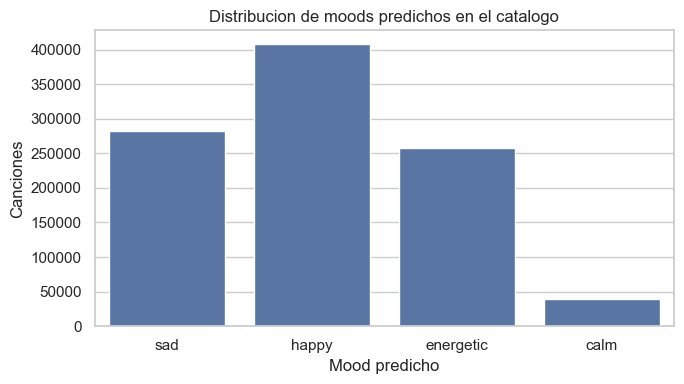

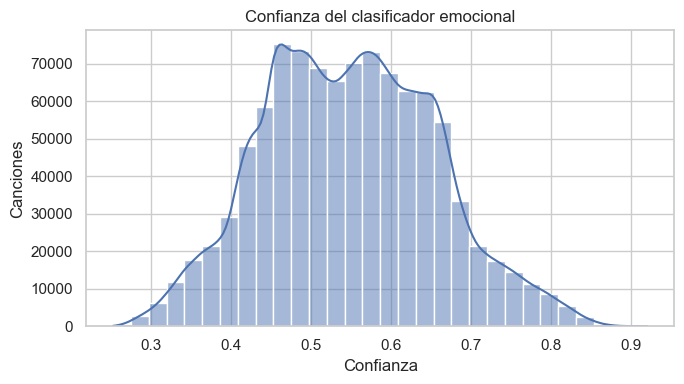

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))
sns.countplot(data=classified_tracks, x="predicted_mood", order=list(MOOD_TO_LABEL.keys()))
plt.title("Distribucion de moods predichos en el catalogo")
plt.xlabel("Mood predicho")
plt.ylabel("Canciones")
plt.tight_layout()
plt.savefig(plots_dir / "classified_mood_distribution.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(classified_tracks["mood_confidence"], bins=30, kde=True)
plt.title("Confianza del clasificador emocional")
plt.xlabel("Confianza")
plt.ylabel("Canciones")
plt.tight_layout()
plt.savefig(plots_dir / "classified_mood_confidence.png", dpi=160)
plt.show()

# Conclusion

- Se observa un desequilibrio en las clases clasificadas, eso se debe a que principalmente en la musica y sobre todo en plataformas como Spotify, la musica predominante es energica, alegre o triste, pero musica que transmita calma no se suele destilar mucho por lo que los claisficados en esta clase son pocos.

## 4. Dataset de entrenamiento por weak supervision

Training rows: 200,000
X_train: (160000, 25) | X_test: (40000, 25)


,activity,user_mood,target_score
0,trabajar,energetic,0.366621
1,trabajar,sad,0.405616
2,correr,calm,0.307689
3,relajarse,calm,0.456156
4,dormir,energetic,0.420250


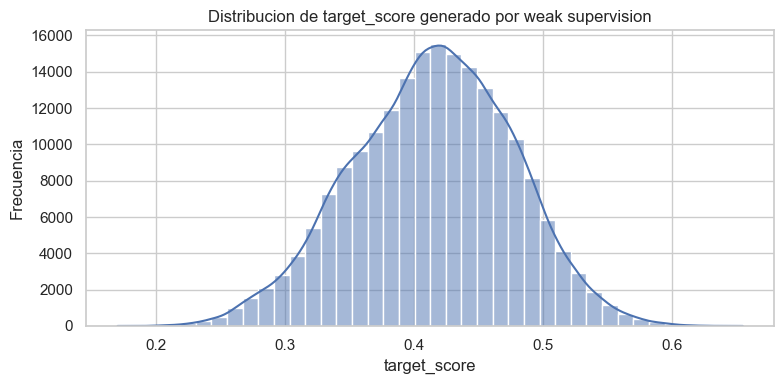

In [5]:
train_df = build_weak_supervision_dataset(classified_tracks)
train_df = sample_recommender_training_frame(train_df, MAX_RECOMMENDER_TRAINING_ROWS)

X = train_df[MODEL_INPUT_COLS]
y = train_df["target_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training rows: {len(train_df):,}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
display(train_df[["activity", "user_mood", "target_score"]].head())

plt.figure(figsize=(8, 4))
sns.histplot(train_df["target_score"], bins=40, kde=True)
plt.title("Distribucion de target_score generado por weak supervision")
plt.xlabel("target_score")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(plots_dir / "target_score_distribution.png", dpi=160)
plt.show()

## 5. Entrenamiento y validacion de modelos

In [6]:
model_results, fitted_models = train_candidate_recommenders(X_train, y_train, X_test, y_test)
metrics_df = pd.DataFrame(model_results).sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
best_model_name = str(metrics_df.iloc[0]["model"])
recommender = fitted_models[best_model_name].best_estimator_

X_test_eval, y_test_eval = sample_xy(X_test, y_test, MAX_RECOMMENDER_EVAL_ROWS, "test")
X_test_eval = X_test_eval.fillna(0.0).astype(np.float32).reset_index(drop=True)
y_test_eval = y_test_eval.reset_index(drop=True).astype(np.float32)
recommender_predictions_df = pd.concat([
    pd.DataFrame({
        "model": model_name,
        "real_score": y_test_eval.to_numpy(),
        "predicted_score": np.clip(search.best_estimator_.predict(X_test_eval), 0.0, 1.0),
    })
    for model_name, search in fitted_models.items()
], ignore_index=True)
recommender_predictions_df["residual"] = recommender_predictions_df["real_score"] - recommender_predictions_df["predicted_score"]

display(metrics_df.style.format(precision=4).set_caption("Metricas de validacion: MAE, RMSE y R2"))
print(f"Mejor modelo: {best_model_name}")

,model,best_params,best_cv_rmse,mae,mse,rmse,r2
1,mlp,"{'model__alpha': 0.0005, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.0005}",0.0107,0.0061,0.0001,0.0106,0.9712
0,random_forest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}",0.0139,0.0093,0.0002,0.0134,0.9535


Mejor modelo: mlp


# Conclusion

Error global muy bajo y R2 alto indican buen ajuste en la tarea de regresión de scores, pero el fuerte desbalance de moods y la generación por weak supervision pueden introducir sesgos y reducir la calidad para la clase calm.

Riesgos en producción: Subrepresentación de calm → recomendaciones que infrarrepresentan actividades asociadas a música tranquila; posible sobreconfianza en predicciones para clases dominantes.

## 6. Graficas comparativas del recomendador

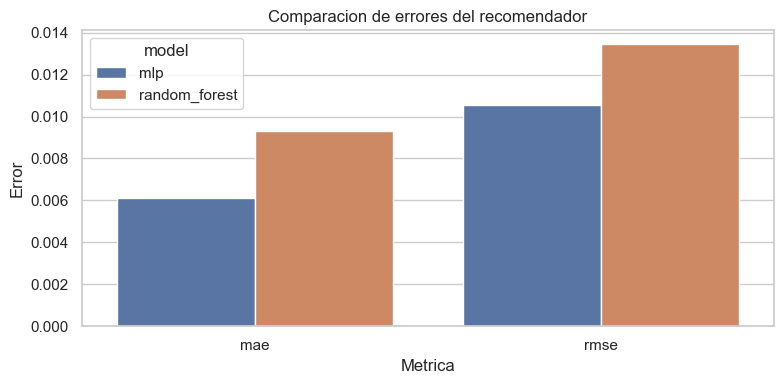

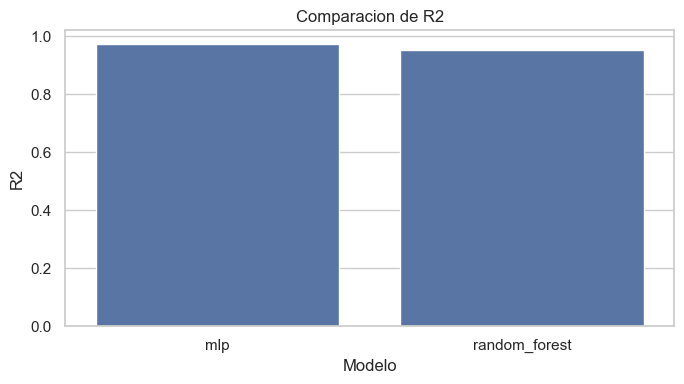

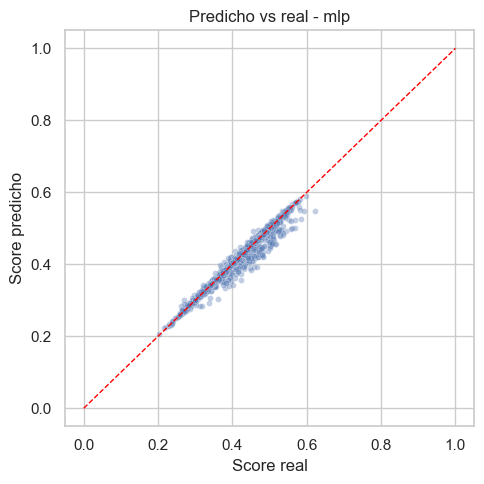

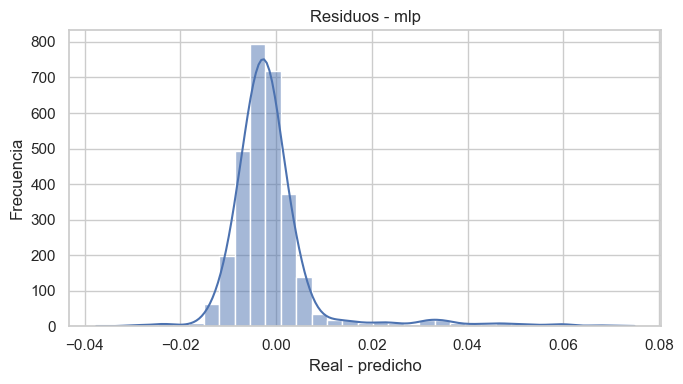

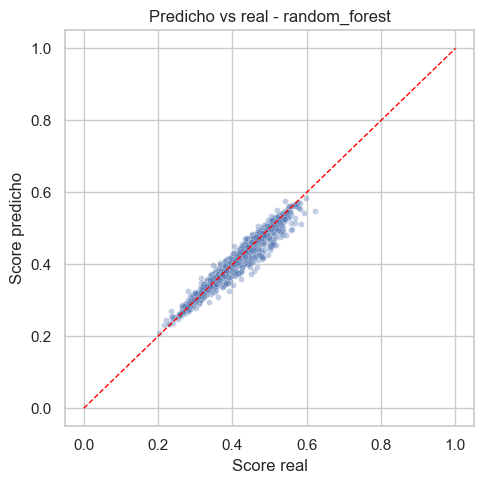

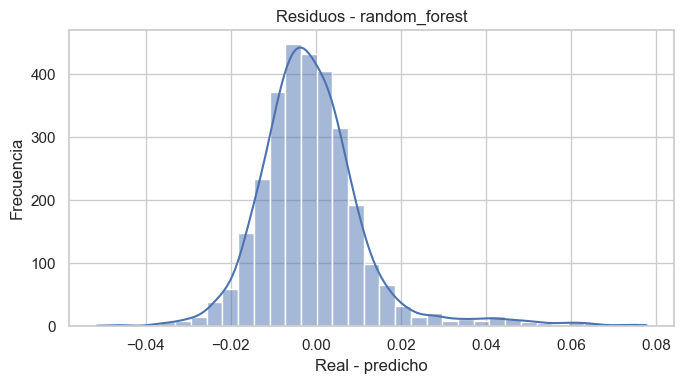

In [7]:
metric_plot_df = metrics_df.melt(id_vars="model", value_vars=["mae", "rmse"], var_name="metric", value_name="error")
plt.figure(figsize=(8, 4))
sns.barplot(data=metric_plot_df, x="metric", y="error", hue="model")
plt.title("Comparacion de errores del recomendador")
plt.xlabel("Metrica")
plt.ylabel("Error")
plt.tight_layout()
plt.savefig(plots_dir / "recommender_error_comparison.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=metrics_df, x="model", y="r2")
plt.title("Comparacion de R2")
plt.xlabel("Modelo")
plt.ylabel("R2")
plt.tight_layout()
plt.savefig(plots_dir / "recommender_r2_comparison.png", dpi=160)
plt.show()

for model_name in metrics_df["model"]:
    model_pred = recommender_predictions_df[recommender_predictions_df["model"] == model_name].sample(
        min(3000, (recommender_predictions_df["model"] == model_name).sum()),
        random_state=RANDOM_STATE,
    )
    plt.figure(figsize=(5, 5))
    sns.scatterplot(data=model_pred, x="real_score", y="predicted_score", alpha=0.35, s=18)
    plt.plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=1)
    plt.title(f"Predicho vs real - {model_name}")
    plt.xlabel("Score real")
    plt.ylabel("Score predicho")
    plt.tight_layout()
    plt.savefig(plots_dir / f"recommender_predicted_vs_real_{model_name}.png", dpi=160)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.histplot(model_pred["residual"], bins=35, kde=True)
    plt.title(f"Residuos - {model_name}")
    plt.xlabel("Real - predicho")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(plots_dir / f"recommender_residuals_{model_name}.png", dpi=160)
    plt.show()

# Conclusion 

- Las gráficas de errores muestran que el mlp tiene menor MAE y RMSE que random_forest, indicando mejor precisión global.
- La comparación de R2 también favorece a mlp, lo que sugiere mejor capacidad explicativa del score.
- En los dispersogramas “predicho vs real”, ambos modelos siguen la diagonal, pero mlp se concentra más cerca de la línea ideal; random_forest   presenta mayor dispersión, sobre todo en valores intermedios/altos.
- Los residuos están centrados alrededor de 0 en ambos casos, sin sesgo fuerte, pero la distribución del mlp es más estrecha, señal de menor error y mayor estabilidad.
- En conjunto, el mlp es el modelo más fiable para producción; random_forest queda como alternativa secundaria.

## 7. Importancia de variables del mejor modelo

In [8]:
best_estimator = recommender.named_steps["model"] if hasattr(recommender, "named_steps") else recommender
if hasattr(best_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": MODEL_INPUT_COLS,
        "importance": best_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(15))
    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature")
    plt.title(f"Importancia de variables - {best_model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig(plots_dir / f"recommender_feature_importance_{best_model_name}.png", dpi=160)
    plt.show()
else:
    print("El mejor modelo no expone feature_importances_.")

El mejor modelo no expone feature_importances_.


El atributo feature_importances solo lo expone Random Forest a diferencia de MPL

## 8. Guardado de artefactos

In [9]:
for model_name, search in fitted_models.items():
    joblib.dump(search.best_estimator_, ROOT / "models" / f"activity_recommender_{model_name}.joblib")

joblib.dump(recommender, ROOT / "models" / "activity_recommender_best.joblib")
joblib.dump(recommender, ROOT / "models" / "activity_recommender_mlp.joblib")

metrics_df.to_csv(output_data_dir / "recommender_metrics.csv", index=False)
recommender_predictions_df.to_csv(output_data_dir / "recommender_predictions.csv", index=False)
train_df.sample(min(5000, len(train_df)), random_state=RANDOM_STATE).to_csv(
    output_data_dir / "recommender_training_sample.csv",
    index=False,
)

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "random_state": RANDOM_STATE,
    "model_type": best_model_name,
    "best_model": best_model_name,
    "input_columns": MODEL_INPUT_COLS,
    "activity_profile_columns": ACTIVITY_PROFILE_COLS,
    "known_activities": KNOWN_ACTIVITIES,
    "tracks_rows": int(len(classified_tracks)),
    "training_rows": int(len(train_df)),
    "max_training_rows": MAX_RECOMMENDER_TRAINING_ROWS,
    "metrics": {
        "mae": float(metrics_df.iloc[0]["mae"]),
        "mse": float(metrics_df.iloc[0]["mse"]),
        "rmse": float(metrics_df.iloc[0]["rmse"]),
        "r2": float(metrics_df.iloc[0]["r2"]),
    },
    "model_comparison": model_results,
    "note": "Weak supervision: las puntuaciones objetivo se generan con reglas musicales interpretables.",
}
(ROOT / "models" / "activity_recommender_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
if UPLOAD_TO_S3:
    settings = load_settings()
    upload_artifacts(settings, ROOT / "models", output_data_dir, S3_RECOMMENDER_PREFIX)
    print("Modelo subido a S3 en ",settings.bucket_name,"/models")

print(f"Recomendador final: {ROOT / 'models' / 'activity_recommender_best.joblib'}")
print(f"Compatibilidad app: {ROOT / 'models' / 'activity_recommender_mlp.joblib'}")
print(f"Metricas: {output_data_dir / 'recommender_metrics.csv'}")
print(f"Graficas: {plots_dir}")

Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_recommender_best.joblib
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_recommender_metadata.json
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_recommender_mlp.joblib
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_recommender_random_forest.joblib
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_text_interpreter.joblib
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/activity_text_interpreter_metadata.json
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/mood_best_model.joblib
Subido a s3://music-recommender-lake-807744154206/models/activity_recommender/models/mood_best_model.pt
Subido a s3://music-recommender-lake-807744154206/models/activi